## De novo inhibitor generation via reinforcement learning 

*Building a reinforcement learning agent which generates EGFR inhibitor from previously built guardrails.*

## Abstract

Notebook 07 optimised molecules with a genetic algorithm. Its fitness was a multi-objective score: predicted EGFR pIC50, drug-likeness (QED), novelty within an applicability-domain band, synthesizability, and structural-alert filters. This notebook keeps that exact score but changes the optimiser. A genetic algorithm only selects good molecules; here a reinforcement-learning agent (REINVENT), built on an RNN pretrained on ChEMBL, updates its own generative policy to make high-scoring molecules more likely. The question is simple: at an equal budget of oracle evaluations, does an agent that learns beat a search that does not? Averaged over three seeds, the RL agent is more sample-efficient and reaches a higher composite score (0.52 against 0.46). It is also far more diverse, with about 72 distinct Bemis-Murcko scaffolds in its top 100 against 17 for the genetic algorithm, both staying drug-like (QED around 0.9). A control on raw activity tells the opposite story: without guardrails the genetic algorithm reaches a higher predicted pIC50, but by exploiting the model outside its applicability domain (mean QED 0.04). The activities are predicted by a QSAR model, not measured, and the agent benefits from a ChEMBL prior that the genetic algorithm does not have. The comparison holds only because the reward and the budget are identical.

## Methods

**Reward.** Both optimisers maximised the same objective, the multi-objective score of notebook 07. For a molecule it multiplies four desirabilities: predicted EGFR activity (pIC50 from the notebook-06 XGBoost model on 2048-bit
ECFP4 fingerprints plus seven physicochemical descriptors, scaled to [0,1]), drug-likeness (QED), novelty (maximum Tanimoto to 2000 sampled training molecules, rewarded only inside a 0.3–0.7 band), and synthesizability (SA score mapped to [0,1]). A hard filter sets the score to zero for disallowed elements, molecular weight outside 150–600, absolute formal charge above one, or a PAINS/Brenk alert. The score was implemented once and shared by both methods: it served as the genetic algorithm's fitness and was wrapped as a single custom scoring component for the RL agent.

**Genetic algorithm (baseline).** The notebook-07 elitist genetic algorithm was reused. A population of 100 molecules was initialised from real training molecules; each generation kept the 20 best and regenerated the rest by SELFIES mutations (one to three token edits), which always yield valid molecules. Evaluations were cached so that each distinct molecule counted once toward the oracle budget.

**Reinforcement-learning agent.** The agent was REINVENT 4 (v4.8.24) run in staged-learning mode on CPU. Its generative policy was a recurrent network initialised from a public de novo prior pretrained on PubChem. Training used the DAP strategy (sigma = 128), a learning rate of 1e-4, and a batch size of 64; REINVENT's built-in diversity filter was disabled so the agent optimised the shared score alone. Each run lasted 190 steps, about 12,000 reward evaluations.

**Comparison.** The two methods were compared at equal oracle budget by tracking the best composite score reached as a function of cumulative evaluations, with three random seeds each. Diversity was measured as the number of distinct Bemis-Murcko scaffolds among the 100 top-scoring molecules. All runs ran under Ubuntu (WSL) in a dedicated conda environment.

## Results
### RL baseline: EGFR activity reward only

First RL run. The reward is only the EGFR pIC50 predicted by the XGBoost model from notebook 06, mapped to [0,1] by a sigmoid (5 → 0, 9 → 1). 


In [2]:
from rdkit import RDLogger
RDLogger.DisableLog("rdApp.*")

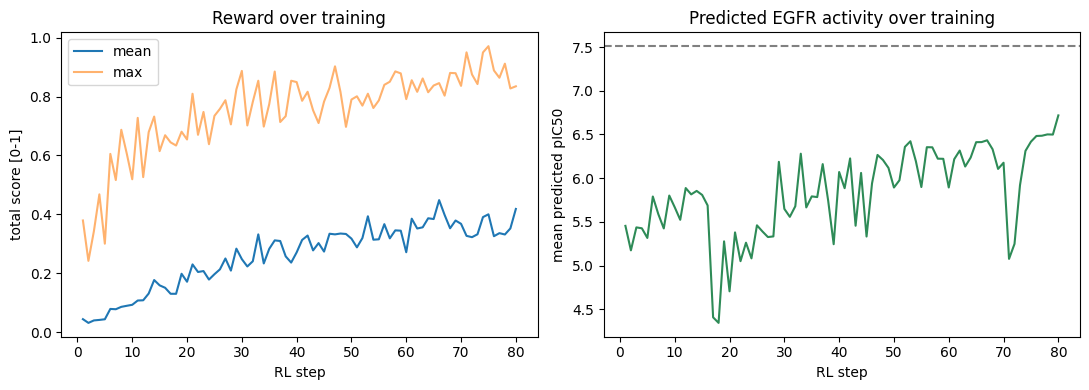

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/mnt/c/Users/coure/Projects/cheminformatics/rl_runs/egfr_baseline/egfr_rl_1.csv")
per_step = df.groupby("step").agg(
    mean_score=("Score", "mean"),
    max_score=("Score", "max"),
    mean_pic50=("EGFR pIC50 (raw)", "mean"),
).reset_index()

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(per_step["step"], per_step["mean_score"], label="mean")
ax[0].plot(per_step["step"], per_step["max_score"], label="max", alpha=0.6)
ax[0].set_xlabel("RL step"); ax[0].set_ylabel("total score [0-1]")
ax[0].set_title("Reward over training"); ax[0].legend()

ax[1].plot(per_step["step"], per_step["mean_pic50"], color="seagreen")
ax[1].axhline(7.51, ls="--", color="gray")            # gefitinib, ref
ax[1].set_xlabel("RL step"); ax[1].set_ylabel("mean predicted pIC50")
ax[1].set_title("Predicted EGFR activity over training")
plt.tight_layout(); plt.show()


In [4]:
import py3Dmol
from rdkit import Chem
from rdkit.Chem import AllChem

best = df.loc[df["Score"].idxmax()]
print("best SMILES :", best["SMILES"])
print("score :", round(best["Score"], 3), "| predicted pIC50 :", round(best["EGFR pIC50 (raw)"], 2))

m = Chem.AddHs(Chem.MolFromSmiles(best["SMILES"]))
AllChem.EmbedMolecule(m, randomSeed=42); AllChem.MMFFOptimizeMolecule(m)
view = py3Dmol.view(width=450, height=400)
view.addModel(Chem.MolToMolBlock(m), "mol")
view.setStyle({"stick": {}})
view.zoomTo(); view.show()

best SMILES : C=C(Cn1c(-c2c(F)cc3c(-c4c(F)c(OCC)cc(F)c4Cl)nncc3c2F)c(C2CC2)c(=O)n(C(C)(C)C)c1=O)C(=O)O
score : 0.971 | predicted pIC50 : 8.22


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

### RL guided: guardrails from notebook 07

Second RL run. The reward is the multi-objective score from notebook 07.


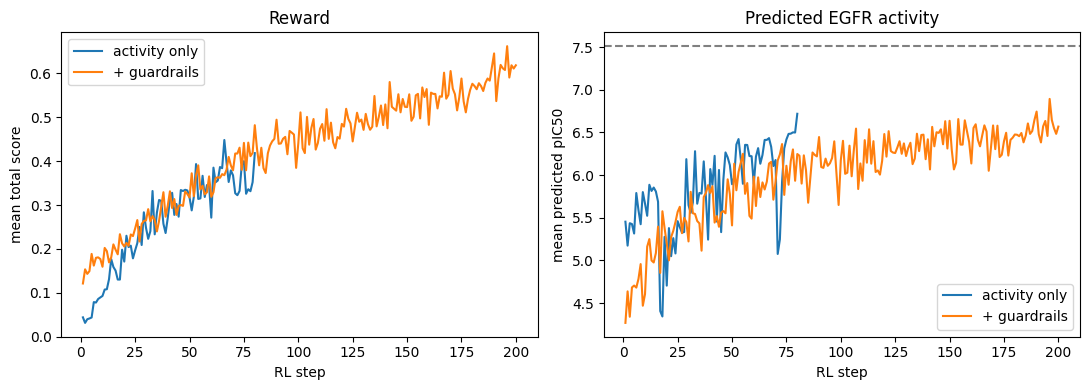

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

BASE = "/mnt/c/Users/coure/Projects/cheminformatics/rl_runs/egfr_baseline/egfr_rl_1.csv"
GUARD = "/mnt/c/Users/coure/Projects/cheminformatics/rl_runs/egfr_guarded/egfr_guarded_1.csv"

def per_step(path):
    df = pd.read_csv(path)
    return df.groupby("step").agg(score=("Score", "mean"),
                                  pic50=("EGFR pIC50 (raw)", "mean")).reset_index()

b, g = per_step(BASE), per_step(GUARD)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(b["step"], b["score"], label="activity only")
ax[0].plot(g["step"], g["score"], label="+ guardrails")
ax[0].set_xlabel("RL step"); ax[0].set_ylabel("mean total score"); ax[0].set_title("Reward"); ax[0].legend()

ax[1].plot(b["step"], b["pic50"], label="activity only")
ax[1].plot(g["step"], g["pic50"], label="+ guardrails")
ax[1].axhline(7.51, ls="--", color="gray")   # gefitinib
ax[1].set_xlabel("RL step"); ax[1].set_ylabel("mean predicted pIC50")
ax[1].set_title("Predicted EGFR activity"); ax[1].legend()
plt.tight_layout(); plt.show()

In [6]:
import py3Dmol
from rdkit import Chem
from rdkit.Chem import AllChem

guard = pd.read_csv(GUARD)
print("colonnes dispo :", list(guard.columns))     # pour voir les noms exacts des composants

best = guard.loc[guard["Score"].idxmax()]
print("\nbest SMILES :", best["SMILES"], "| score :", round(best["Score"], 3))
for col in ["EGFR pIC50 (raw)", "QED", "Molecular weight (raw)", "SA score"]:
    if col in guard.columns:
        print(f"  {col}: {round(float(best[col]), 3)}")

m = Chem.AddHs(Chem.MolFromSmiles(best["SMILES"]))
AllChem.EmbedMolecule(m, randomSeed=42); AllChem.MMFFOptimizeMolecule(m)
view = py3Dmol.view(width=450, height=400)
view.addModel(Chem.MolToMolBlock(m), "mol"); view.setStyle({"stick": {}}); view.zoomTo(); view.show()

colonnes dispo : ['Agent', 'Prior', 'Target', 'Score', 'SMILES', 'SMILES_state', 'Scaffold', 'EGFR pIC50', 'EGFR pIC50 (raw)', 'QED', 'QED (raw)', 'Molecular weight', 'Molecular weight (raw)', 'SA score', 'SA score (raw)', 'Unwanted SMARTS', 'Unwanted SMARTS (raw)', 'matchting_patterns (Unwanted SMARTS)', 'step']

best SMILES : CC1CCCN2CC1CN(C)C(c1cc(NCc3ccno3)ncn1)C2 | score : 1.268
  EGFR pIC50 (raw): 8.245
  QED: 0.902
  Molecular weight (raw): 356.474
  SA score: 5.006


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

### Comparison GA vs RL

In [7]:
import random
import numpy as np, pandas as pd, joblib
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem import Descriptors, rdMolDescriptors, AllChem
from rdkit.Chem.Scaffolds import MurckoScaffold
import selfies as sf

REPO = "/mnt/c/Users/coure/Projects/cheminformatics"
models = joblib.load(f"{REPO}/models/target_models.joblib")
ref_smiles = joblib.load(f"{REPO}/models/train_smiles.joblib")
egfr = models["EGFR"]

def featurize_one(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None: return None
    fp = np.array(AllChem.GetMorganFingerprintAsBitVect(mol, 2, 2048))
    desc = [Descriptors.MolLogP(mol), Descriptors.MolWt(mol), Descriptors.NumHDonors(mol),
            Descriptors.NumHAcceptors(mol), Descriptors.TPSA(mol),
            rdMolDescriptors.CalcNumAromaticRings(mol), Descriptors.NumRotatableBonds(mol)]
    return np.hstack([fp, desc]).astype(np.float32)

ALPHABET = list(sf.get_semantic_robust_alphabet())
def mutate(smiles, n_mut=1):
    try: tokens = list(sf.split_selfies(sf.encoder(smiles)))
    except Exception: return None
    for _ in range(n_mut):
        if not tokens: break
        op = random.choice(["replace","insert","delete"]); i = random.randrange(len(tokens))
        if op == "replace": tokens[i] = random.choice(ALPHABET)
        elif op == "insert": tokens.insert(i, random.choice(ALPHABET))
        elif op == "delete" and len(tokens) > 1: tokens.pop(i)
    try: return sf.decoder("".join(tokens))
    except Exception: return None

In [8]:
import os, sys
from rdkit import DataStructs
from rdkit.Chem import QED, RDConfig, FilterCatalog
from rdkit.Chem.FilterCatalog import FilterCatalogParams
sys.path.append(os.path.join(RDConfig.RDContribDir, "SA_Score"))
import sascorer

ALLOWED = {"C","N","O","F","S","Cl","Br"}
_p = FilterCatalogParams()
_p.AddCatalog(FilterCatalogParams.FilterCatalogs.PAINS)
_p.AddCatalog(FilterCatalogParams.FilterCatalogs.BRENK)
_CAT = FilterCatalog.FilterCatalog(_p)
REF_FPS = [AllChem.GetMorganFingerprintAsBitVect(m,2,2048)
           for s in random.Random(42).sample(list(ref_smiles), 2000) if (m := Chem.MolFromSmiles(s))]

def passes_guards(mol):
    if any(a.GetSymbol() not in ALLOWED for a in mol.GetAtoms()): return False
    if not (150 <= Descriptors.MolWt(mol) <= 600): return False
    if abs(Chem.GetFormalCharge(mol)) > 1: return False
    if _CAT.HasMatch(mol): return False
    return True
def ad_desir(sim):
    if sim <= 0.3: return sim/0.3
    if sim >= 0.7: return max(0.0,(1.0-sim)/0.3)
    return 1.0
def multi_fitness(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None or not passes_guards(mol): return 0.0
    x = featurize_one(smiles)
    pic50_d = max(0.0, min(float(egfr.predict(x.reshape(1,-1))[0])/10.0, 1.0))
    q = QED.qed(mol)
    sim = max(DataStructs.BulkTanimotoSimilarity(AllChem.GetMorganFingerprintAsBitVect(mol,2,2048), REF_FPS))
    sa = (10.0 - sascorer.calculateScore(mol))/9.0
    return pic50_d * q * ad_desir(sim) * sa

In [9]:
random.seed(0)
oracle_calls, best_so_far = 0, -np.inf
cache, ga_history = {}, []

def ga_oracle(smiles):
    global oracle_calls, best_so_far
    if smiles in cache:                     
        return cache[smiles]
    oracle_calls += 1
    x = featurize_one(smiles)
    val = float(egfr.predict(x.reshape(1, -1))[0]) if x is not None else -np.inf
    cache[smiles] = val
    best_so_far = max(best_so_far, val)
    return val

pop = random.sample(ref_smiles, 100)
POP, KEEP, GEN = 100, 20, 160
for gen in range(GEN):
    scores = [ga_oracle(s) for s in pop]
    order = np.argsort(scores)[::-1]
    parents = [pop[i] for i in order[:KEEP]]
    ga_history.append((oracle_calls, best_so_far))
    children = []
    while len(children) < POP - KEEP:
        c = mutate(random.choice(parents), n_mut=random.randint(1, 3))
        if c is not None: children.append(c)
    pop = parents + children

ga_final_pop = pop
print("GA finished | oracle calls:", oracle_calls, "| best pIC50:", round(best_so_far, 2))

GA terminé | appels oracle: 12125 | meilleur pIC50: 9.39


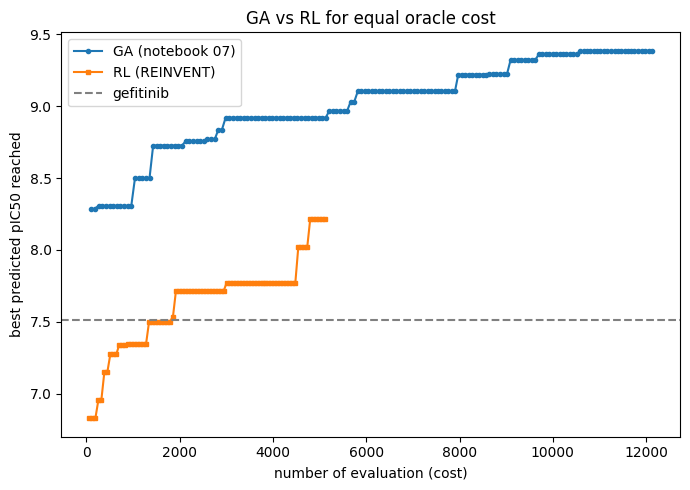

In [10]:
BATCH = 64
rl = pd.read_csv(f"{REPO}/rl_runs/egfr_baseline/egfr_rl_1.csv")
rl_step = rl.groupby("step")["EGFR pIC50 (raw)"].max().reset_index()
rl_step["calls"] = rl_step["step"] * BATCH
rl_step["best"] = rl_step["EGFR pIC50 (raw)"].cummax()

ga = pd.DataFrame(ga_history, columns=["calls", "best"])

plt.figure(figsize=(7, 5))
plt.plot(ga["calls"], ga["best"], "-o", ms=3, label="GA (notebook 07)")
plt.plot(rl_step["calls"], rl_step["best"], "-s", ms=3, label="RL (REINVENT)")
plt.axhline(7.51, ls="--", color="gray", label="gefitinib")
plt.xlabel("number of evaluation (cost)"); plt.ylabel("best predicted pIC50 reached")
plt.title("GA vs RL for equal oracle cost"); plt.legend()
plt.tight_layout(); plt.show()

In [11]:
def scaffold(s):
    m = Chem.MolFromSmiles(s)
    return MurckoScaffold.MurckoScaffoldSmiles(mol=m) if m else None

ga_top = sorted(cache, key=lambda s: cache[s], reverse=True)[:100]
ga_scaff = len({scaffold(s) for s in ga_top if scaffold(s)})

rl_top = rl.sort_values("EGFR pIC50 (raw)", ascending=False)["SMILES"].head(100)
rl_scaff = len({scaffold(s) for s in rl_top if scaffold(s)})

print("Distincts Murcko scaffolds in top 100 — GA:", ga_scaff, "| RL:", rl_scaff)

Distincts Murcko scaffolds in top 100 — GA: 17 | RL: 100


In [12]:
from rdkit.Chem import QED, DataStructs
REF_FPS = [AllChem.GetMorganFingerprintAsBitVect(m, 2, 2048)
           for s in random.sample(ref_smiles, 2000) if (m := Chem.MolFromSmiles(s))]

def qed_of(s):
    m = Chem.MolFromSmiles(s); return QED.qed(m) if m else np.nan
def max_tani(s):
    m = Chem.MolFromSmiles(s)
    if m is None: return np.nan
    q = AllChem.GetMorganFingerprintAsBitVect(m, 2, 2048)
    return max(DataStructs.BulkTanimotoSimilarity(q, REF_FPS))

for name, top in [("GA", ga_top), ("RL", list(rl_top))]:
    q = np.nanmean([qed_of(s) for s in top])
    t = np.nanmean([max_tani(s) for s in top])
    print(f"{name} top-100 | QED moyen: {q:.2f} | Tanimoto max au train (domaine): {t:.2f}")

GA top-100 | QED moyen: 0.06 | Tanimoto max au train (domaine): 0.31
RL top-100 | QED moyen: 0.17 | Tanimoto max au train (domaine): 0.25


In [13]:
random.seed(0)
oracle_calls, best_so_far = 0, -np.inf
cache, ga_history = {}, []                 

def ga_score(s):
    global oracle_calls, best_so_far
    if s in cache:
        return cache[s]
    oracle_calls += 1
    v = multi_fitness(s)                    
    cache[s] = v
    best_so_far = max(best_so_far, v)
    return v

pop = random.sample(ref_smiles, 100)
POP, KEEP, GEN = 100, 20, 160
for gen in range(GEN):
    scores = [ga_score(s) for s in pop]
    order = np.argsort(scores)[::-1]
    parents = [pop[i] for i in order[:KEEP]]
    ga_history.append((oracle_calls, best_so_far))
    children = []
    while len(children) < POP - KEEP:
        c = mutate(random.choice(parents), n_mut=random.randint(1, 3))
        if c is not None:
            children.append(c)
    pop = parents + children

ga_final_pop = pop
print("guarded GA | calls:", oracle_calls, "| best composite:", round(best_so_far, 3))

GA guardé | appels: 9733 | best composite: 0.574


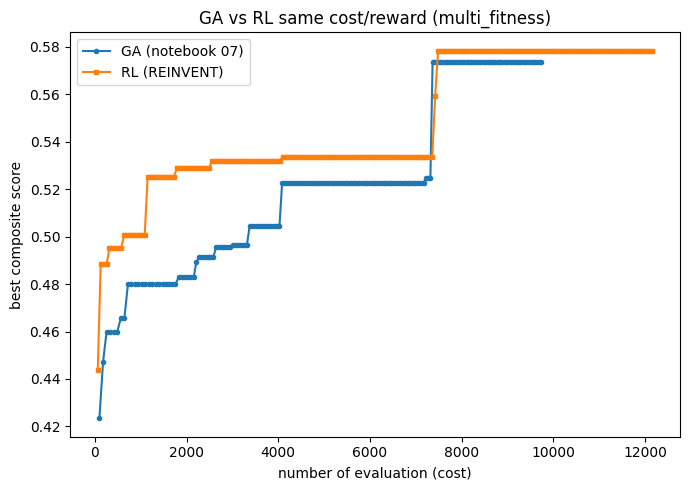

In [14]:
REPO = "/mnt/c/Users/coure/Projects/cheminformatics"

rl = pd.read_csv(f"{REPO}/rl_runs/egfr_multifitness/egfr_multifitness_1.csv")
rl_step = rl.groupby("step")["Score"].max().reset_index()
rl_step["calls"] = rl_step["step"] * 64
rl_step["best"]  = rl_step["Score"].cummax()

ga = pd.DataFrame(ga_history, columns=["calls", "best"])

plt.figure(figsize=(7, 5))
plt.plot(ga["calls"], ga["best"], "-o", ms=3, label="GA (notebook 07)")
plt.plot(rl_step["calls"], rl_step["best"], "-s", ms=3, label="RL (REINVENT)")
plt.xlabel("number of evaluation (cost)")
plt.ylabel("best composite score")
plt.title("GA vs RL same cost/reward (multi_fitness)")
plt.legend(); plt.tight_layout(); plt.show()

In [15]:
def scaffold(s):
    m = Chem.MolFromSmiles(s)
    return MurckoScaffold.MurckoScaffoldSmiles(mol=m) if m else None

ga_top = sorted(cache, key=lambda s: cache[s], reverse=True)[:100]
rl_top = rl.sort_values("Score", ascending=False)["SMILES"].drop_duplicates().head(100).tolist()

def summarize(name, top):
    scaff = len({scaffold(s) for s in top if scaffold(s)})
    q = np.nanmean([QED.qed(m) if (m := Chem.MolFromSmiles(s)) else np.nan for s in top])
    comp = np.nanmean([multi_fitness(s) for s in top])
    print(f"{name} top-100 | distinct scaffolds : {scaff} | mean QED : {q:.2f} | mean composite : {comp:.3f}")

summarize("GA", ga_top)
summarize("RL", list(rl_top))

GA top-100 | distinct scaffolds : 41 | mean QED : 0.86 | mean composite : 0.465
RL top-100 | distinct scaffolds : 79 | mean QED : 0.92 | mean composite : 0.518


### 3 Seeds comparison

In [16]:
def run_ga_seeded(seed, POP=100, KEEP=20, GEN=160):
    random.seed(seed)
    n_calls, best, cache, hist = [0], [-np.inf], {}, []
    def score(s):
        if s in cache: return cache[s]
        n_calls[0] += 1
        v = multi_fitness(s); cache[s] = v
        if v > best[0]: best[0] = v
        return v
    pop = random.sample(ref_smiles, POP)
    for _ in range(GEN):
        sc = [score(s) for s in pop]
        parents = [pop[i] for i in np.argsort(sc)[::-1][:KEEP]]
        hist.append((n_calls[0], best[0]))
        children = []
        while len(children) < POP - KEEP:
            c = mutate(random.choice(parents), n_mut=random.randint(1, 3))
            if c is not None: children.append(c)
        pop = parents + children
    top = sorted(cache, key=lambda s: cache[s], reverse=True)[:100]
    scaff = len({scaffold(s) for s in top if scaffold(s)})
    qed_m = float(np.nanmean([QED.qed(m) if (m := Chem.MolFromSmiles(s)) else np.nan for s in top]))
    comp_m = float(np.nanmean([cache[s] for s in top]))
    return hist, dict(scaffolds=scaff, qed=round(qed_m, 2), composite=round(comp_m, 3))

ga_hists, ga_mets = [], []
for seed in [0, 1, 2]:
    h, m = run_ga_seeded(seed)
    ga_hists.append(h); ga_mets.append(m)
    print(f"GA seed {seed}: {m}")

GA seed 0: {'scaffolds': 41, 'qed': 0.86, 'composite': 0.465}
GA seed 1: {'scaffolds': 18, 'qed': 0.9, 'composite': 0.466}
GA seed 2: {'scaffolds': 28, 'qed': 0.91, 'composite': 0.469}


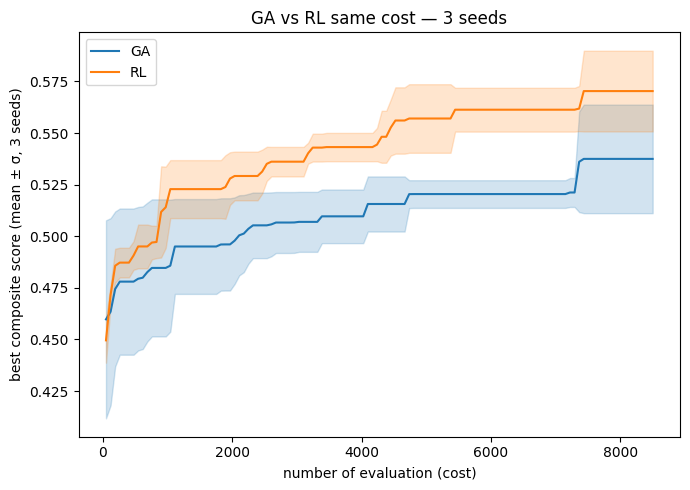

In [17]:
grid = np.linspace(50, 8500, 120)   # budget commun (borné au min des deux méthodes)

def bands(histories):
    M = np.array([np.interp(grid, np.array(h)[:,0], np.array(h)[:,1]) for h in histories])
    return M.mean(0), M.std(0)

ga_mean, ga_std = bands(ga_hists)

rl_hists = []
for s in [0, 1, 2]:
    d = pd.read_csv(f"{REPO}/rl_runs/egfr_mf_seeds/egfr_mf_s{s}_1.csv")
    st = d.groupby("step")["Score"].max().reset_index()
    st["calls"] = st["step"] * 64
    st["best"] = st["Score"].cummax()
    rl_hists.append(list(zip(st["calls"], st["best"])))
rl_mean, rl_std = bands(rl_hists)

plt.figure(figsize=(7, 5))
plt.plot(grid, ga_mean, color="tab:blue", label="GA")
plt.fill_between(grid, ga_mean-ga_std, ga_mean+ga_std, alpha=0.2, color="tab:blue")
plt.plot(grid, rl_mean, color="tab:orange", label="RL")
plt.fill_between(grid, rl_mean-rl_std, rl_mean+rl_std, alpha=0.2, color="tab:orange")
plt.xlabel("number of evaluation (cost)")
plt.ylabel("best composite score (mean ± σ, 3 seeds)")
plt.title("GA vs RL same cost — 3 seeds"); plt.legend()
plt.tight_layout(); plt.show()

In [18]:
def agg(name, mets):
    print(name)
    for k in ["scaffolds", "qed", "composite"]:
        v = [m[k] for m in mets]
        print(f"  {k}: {np.mean(v):.2f} ± {np.std(v):.2f}")

rl_mets = []
for s in [0, 1, 2]:
    d = pd.read_csv(f"{REPO}/rl_runs/egfr_mf_seeds/egfr_mf_s{s}_1.csv")
    top = d.sort_values("Score", ascending=False)["SMILES"].drop_duplicates().head(100).tolist()
    scaff = len({scaffold(x) for x in top if scaffold(x)})
    qed_m = float(np.nanmean([QED.qed(m) if (m := Chem.MolFromSmiles(x)) else np.nan for x in top]))
    comp_m = float(np.nanmean([multi_fitness(x) for x in top]))
    rl_mets.append(dict(scaffolds=scaff, qed=round(qed_m, 2), composite=round(comp_m, 3)))

agg("GA (3 seeds):", ga_mets)
agg("RL (3 seeds):", rl_mets)

GA (3 seeds):
  scaffolds: 29.00 ± 9.42
  qed: 0.89 ± 0.02
  composite: 0.47 ± 0.00
RL (3 seeds):
  scaffolds: 72.33 ± 6.80
  qed: 0.92 ± 0.00
  composite: 0.52 ± 0.00


## Discussion

The benchmark isolates a single variable, the optimiser, and the result holds across seeds: at equal oracle budget and under the same constrained reward, the reinforcement-learning agent reaches a higher composite score than the genetic algorithm and explores far more broadly, with roughly four times as many distinct scaffolds in its top 100. The likely reason lies in how each method works. The genetic algorithm searches locally, by random mutation around its current best individuals, and tends to collapse onto a few scaffold families. The agent instead learns a generative policy over the whole reward landscape, and its pretrained prior spreads probability across many chemotypes.

The control on unconstrained activity carries the deeper lesson. When the reward is the raw predicted pIC50, the genetic algorithm "wins" on the number it optimises, but its molecules are chemically implausible (mean QED 0.04) and exploit the model outside its applicability domain. Which optimiser looks best therefore depends on the reward, not on the search. This is why the comparison is only meaningful under an identical, constrained score, and it is the same reward-hacking failure that the next notebook sets out to control.

Several limitations temper the conclusion. The agent starts from a prior pretrained on PubChem, an advantage the genetic algorithm does not have; part of its edge reflects that head start rather than learning alone, and a fully fair comparison would need to account for it. The composite score is a heuristic built on a QSAR model, so a higher score means a better hypothesis, not a better molecule; only synthesis and assay could confirm activity. The study also rests on a single target, one reward formulation, three seeds, and a small budget-accounting asymmetry that favours the genetic algorithm, whose evaluations are cached while every molecule the agent generates counts. 

## Conclusion and Perspective

Replacing the notebook-07 genetic algorithm with a reinforcement-learning agent, at equal oracle budget and under the same constrained reward, yields a more sample-efficient and far more diverse generator: the agent reaches a higher composite score and covers about four times as many scaffolds among its best molecules, while staying drug-like. The unconstrained control shows why this comparison must be read with care. On raw predicted activity the genetic algorithm reaches higher numbers by exploiting the oracle, so the apparent winner depends on the reward, not on the search. 

Three directions follow directly. The reward is a QSAR model that both optimisers can game, so making it uncertainty-aware, through an ensemble oracle and a pessimistic reward, is the immediate next step and is taken up in notebook 09.
Activity alone is also a weak proxy for a useful molecule: adding orthogonal constraints already available here, in particular selectivity against the hERG channel and a semi-empirical check of physical viability, would steer the agent toward candidates that are not merely high-scoring. 
Finally, the diversity gap argues for treating exploration as a goal in its own right rather than a by-product, for example through scaffold-constrained generation around a known pharmacophore. None of this changes the central lesson: the generator is the easy part, and the reward is where the real difficulty, and the real science, lie.